### Полностью готовая модель с ранней остановкой

### Создание датасета

In [88]:
import struct
import sys
import torchvision
import torch
import json
from array import array
from os import path
BASE_DIR = r'C:\Users\arato\Desktop\It_programms\PyTorch'
train_dataset = torchvision.datasets.MNIST(root=r'C:\Users\arato\Desktop\It_programms\PyTorch', train=True, download=True)
test_dataset = torchvision.datasets.MNIST(root=r'C:\Users\arato\Desktop\It_programms\PyTorch', train=False, download=True)

In [89]:
import os
import struct
import numpy as np
from array import array
from os import path
from PIL import Image

def read(dataset):
    if dataset == "training":
        path_img = r"C:\Users\arato\Desktop\It_programms\PyTorch\MNIST\raw\train-images-idx3-ubyte"
        path_lbl = r"C:\Users\arato\Desktop\It_programms\PyTorch\MNIST\raw\train-labels-idx1-ubyte"
    elif dataset == "testing":
        path_img = r"C:\Users\arato\Desktop\It_programms\PyTorch\MNIST\raw\t10k-images-idx3-ubyte"
        path_lbl = r"C:\Users\arato\Desktop\It_programms\PyTorch\/MNIST\raw\t10k-labels-idx1-ubyte"
    else:
        raise ValueError("dataset must be 'testing' or 'training'")

    with open(path_lbl, 'rb') as f_label:
        _, size = struct.unpack(">II", f_label.read(8))
        lbl = array("B", f_label.read())

    with open(path_img, 'rb') as f_img:
        _, size, rows, cols = struct.unpack(">IIII", f_img.read(16))
        img = array("B", f_img.read())

    return lbl, img, size, rows, cols


def write_dataset(labels, data, size, rows, cols, output_dir):
    # создаём папки class_0 ... class_9
    for c in range(10):
        os.makedirs(path.join(output_dir, f"class_{c}"), exist_ok=True)

    # весь массив пикселей -> [size, rows, cols]
    imgs = np.frombuffer(data, dtype=np.uint8).reshape(size, rows, cols)

    # каждую картинку сохраняем в папку её класса
    for i, label in enumerate(labels):
        out = path.join(output_dir, f"class_{label}", f"{i}.png")
        Image.fromarray(imgs[i]).save(out)


output_path = "/content/mnist"

for dataset in ["training", "testing"]:
    write_dataset(*read(dataset), path.join(output_path, dataset))

In [90]:
if not os.path.isdir("dataset"):
    os.mkdir("dataset")

img = np.random.randint(0, 50, [100000, 64, 64], dtype=np.uint8)
square = np.random.randint(100, 200, [100000, 15, 15], dtype=np.uint8)

coords = np.empty([100000, 2])

data = {}

for i in range(img.shape[0]):

    x = np.random.randint(20, 44)
    y = np.random.randint(20, 44)

    img[i,(y-7):(y +8), (x -7):(x + 8)] = square[i]

    coords[i] = [y, x]

    name_img = f'img_{i}.jpeg'
    path_img = os.path. join('dataset/', name_img)

    image = Image. fromarray(img[i])
    image. save(path_img)

    data[name_img] = [y, x]

with open('dataset/coords.json', 'w') as f:
    json.dump(data, f, indent=2)

# os.rmdir('dataset/.ipynb_checkpoints')

In [91]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

import torchvision
from torchvision.transforms import v2

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

import json
from tqdm import tqdm
from PIL import Image

In [92]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [93]:
class MNISTDataset(Dataset):
    def __init__(self,path,transform=None):
        self.path = path
        self.transform = transform

        self.len_dataset=0
        self.data_list=[]

        for path_dir, dir_list, file_list in os.walk(path): #путь папки, вложенные папки и файлы
            if path_dir == path:
                self.classes = dir_list
                self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
                continue

            cls = os.path.basename(path_dir) # Имя последней папки/файла из пути

            for name_file in file_list:
                file_path = os.path.join(path_dir, name_file) #объединяет путь к папке и имя файла в один путь к файлу
                self.data_list.append((file_path, self.class_to_idx[cls])) #добавляет пару «путь к файлу и числовой индекс его класса»

            self.len_dataset += len(file_list)

    def __len__(self):
        return self.len_dataset

    def __getitem__(self, index):
        file_path, target = self.data_list[index]
        sample = np.array(Image.open(file_path))

        if self.transform is not None:
            sample = self.transform(sample)

        return sample, target

In [94]:
transform = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=(0.5,),std=(0.5,))
    ]
)

In [95]:
train = MNISTDataset(r'C:\Users\arato\Desktop\It_programms\PyTorch\mnist\training', transform=transform)
test = MNISTDataset(r'C:\Users\arato\Desktop\It_programms\PyTorch\mnist\testing', transform=transform)

In [96]:
train, val = random_split(train, [0.7,0.3])

In [97]:
train_loader = DataLoader(train, 64, True)
val_loader = DataLoader(val, 64, False)
test_loader = DataLoader(test, 64, False)

In [98]:
class MyModel(nn.Module):
    def __init__(self, input, output):
        super().__init__()
        self.layer_1 = nn.Linear(input, 128)
        self.layer_2 = nn.Linear(128, output)
        self.act = nn.ReLU()

    def forward(self, x):
        x = self.layer_1(x)
        x = self.act(x)
        out = self.layer_2(x)
        return out

model = MyModel(784, 10).to(device)

In [99]:
input = torch.rand([16,784], dtype=torch.float32).to(device)
out = model(input)
out.shape

torch.Size([16, 10])

In [100]:
loss_model = nn.CrossEntropyLoss()
opt = torch.optim.Adam(model.parameters(), lr=0.001)
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5)

In [101]:
EPOCHS = 50

train_loss = []
val_loss = []
train_acc = []
val_acc = []
lr_list = []
best_loss = None
count = 0 # число операций без улучшения модели

In [102]:
for epoch in range(EPOCHS):

    model.train()
    running_train_loss = []
    true_answer = 0
    train_loop = tqdm(train_loader, leave=False)
    for x, targets in train_loop:
        # (batch_size, 1, 28*28) -> (batch_size, 784)
        x = x.reshape(-1,28*28).to(device)
        # (batch_size, int) -> (batch_size, 10), dtype=float32
        targets = targets.reshape(-1).to(torch.int32)
        targets = torch.eye(10)[targets].to(device)

        # Прямой проход + ошибка
        pred = model(x)
        loss = loss_model(pred, targets)

        # Обратный проход
        opt.zero_grad()
        loss.backward()

        # Шаг оптимизации
        opt.step()

        # Добавление значения ф-ии потерь в список
        running_train_loss.append(loss.item())
        mean_train_loss = sum(running_train_loss)/len(running_train_loss)
        true_answer += (pred.argmax(dim=1) == targets.argmax(dim=1)).sum().item()
        # Доп информация
        train_loop.set_description(f'Epoch: [{epoch+1}/{EPOCHS}], train_loss: {mean_train_loss:.4f}')

    # Расчет значения метрики
    running_train_acc = true_answer/len(train)
    # Сохрание значений ф-им потерь и метрики
    train_loss.append(mean_train_loss)
    train_acc.append(running_train_acc)


    # Проверка модели(валидация)
    model.eval()
    with torch.no_grad(): # Запрещаем вычисление градиентов в цикле
        running_val_loss = []
        true_answer = 0
        for x, targets in val_loader:
            x = x.reshape(-1, 28*28).to(device)

            targets = targets.reshape(-1).to(torch.int32)
            targets = torch.eye(10)[targets].to(device)

            # Прямой проход + ошибка
            pred = model(x)
            loss = loss_model(pred, targets)

            # Добавление значения ф-ии потерь в список
            running_val_loss.append(loss.item())
            mean_val_loss = sum(running_val_loss)/len(running_val_loss)

            true_answer += (pred.argmax(dim=1) == targets.argmax(dim=1)).sum().item()
        # Расчет значения метрики
        running_val_acc = true_answer / len(val)

        # Сохрание значений ф-им потерь и метрики
        val_loss.append(mean_val_loss)
        val_acc.append(running_val_acc)

        print(f'Epoch: [{epoch+1}/{EPOCHS}], train_loss: {mean_train_loss:.4f}, train_acc: {running_train_acc:.4f}, val_loss: {mean_val_loss:.4f}, val_acc: {running_val_acc:.4f}')

        if best_loss is None:
            best_loss = mean_val_loss

        if mean_val_loss < best_loss:
            best_loss = mean_val_loss
            count = 0

            checkpoint = {
                'state_model': model.state_dict(),
                'state_opt': opt.state_dict(),
                'state_lr_scheduler': lr_scheduler.state_dict(),
                'loss': {
                    'train_loss': train_loss,
                    'val_loss': val_loss,
                    'best_loss': best_loss
                },
                'metric':{
                    'train_acc': train_acc,
                    'val_acc': val_acc
                },
                'lr': lr_list,
                'epoch':{
                    'EPOCHS': EPOCHS,
                    'save_epoch': epoch
                }
            }

            torch.save(model.state_dict(), f'model_state_dict_epoch_{epoch+1}.pt')
            print(f'На эпохе {epoch+1} сохранена модель со значением ф-ии потерь на валидации: {mean_val_loss:.4f}', end='\n\n')
        if count >= 10:
            print(f'\nОбучение остановлено на эпохе {epoch+1}')
            break

        count += 1

Epoch: [1/50], train_loss: 0.4225, train_acc: 0.8762, val_loss: 0.3003, val_acc: 0.9106


Epoch: [2/50], train_loss: 0.2311, train_acc: 0.9311, val_loss: 0.2046, val_acc: 0.9407
На эпохе 2 сохранена модель со значением ф-ии потерь на валидации: 0.2046



Epoch: [3/50], train_loss: 0.1726, train_acc: 0.9479, val_loss: 0.1685, val_acc: 0.9511
На эпохе 3 сохранена модель со значением ф-ии потерь на валидации: 0.1685



Epoch: [4/50], train_loss: 0.1405, train_acc: 0.9582, val_loss: 0.1605, val_acc: 0.9510
На эпохе 4 сохранена модель со значением ф-ии потерь на валидации: 0.1605



Epoch: [5/50], train_loss: 0.1168, train_acc: 0.9648, val_loss: 0.1246, val_acc: 0.9641
На эпохе 5 сохранена модель со значением ф-ии потерь на валидации: 0.1246



...

Epoch: [21/50], train_loss: 0.0276, train_acc: 0.9902, val_loss: 0.1187, val_acc: 0.9702


Epoch: [22/50], train_loss: 0.0225, train_acc: 0.9929, val_loss: 0.1179, val_acc: 0.9728


Epoch: [23/50], train_loss: 0.0231, train_acc: 0.9921, val_loss: 0.1131, val_acc: 0.9724


Epoch: [24/50], train_loss: 0.0207, train_acc: 0.9930, val_loss: 0.1254, val_acc: 0.9709


Epoch: [25/50], train_loss: 0.0200, train_acc: 0.9933, val_loss: 0.1455, val_acc: 0.9670

Обучение остановлено на эпохе 25


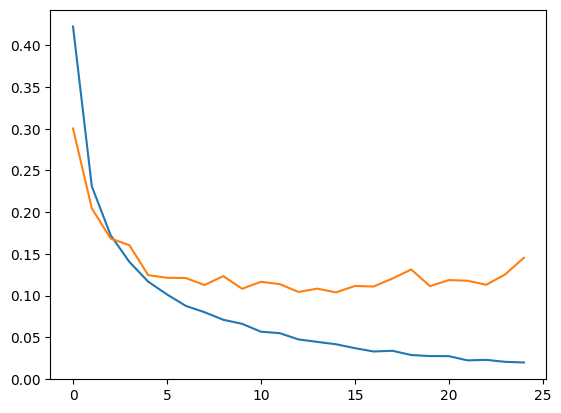

In [103]:
plt.plot(train_loss)
plt.plot(val_loss)

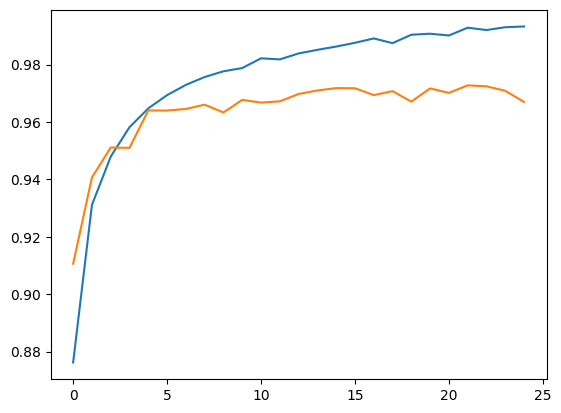

In [104]:
plt.plot(train_acc)
plt.plot(val_acc)

Проверка модели. Данную проверку можно совершать ТОЛЬКО ОДИН раз.

In [107]:
checkpoint = torch.load(r'C:\Users\arato\Desktop\It_programms\PyTorch\model_state_dict_epoch_15.pt')
model.load_state_dict(checkpoint)

<All keys matched successfully>

In [108]:
model.eval()
with torch.no_grad():
    running_test_loss = []
    true_answer = 0
    for x, targets in test_loader:
        x = x.reshape(-1, 28*28).to(device)
        targets = targets.reshape(-1).to(torch.int32)
        targets = torch.eye(10)[targets].to(device)

        pred = model(x)
        loss = loss_model(pred, targets)

        running_test_loss.append(loss.item())
        mean_test_loss = sum(running_test_loss) / len(running_test_loss)

        true_answer += (pred.argmax(dim=1) == targets.argmax(dim=1)).sum().item()

    running_test_acc = true_answer / len(test)

print(f'test_loss = {mean_test_loss:.4f}, test_acc = {running_test_acc:.4f}', end='\n\n')

test_loss = 0.0944, test_acc = 0.9738



На 15 эпохе на валидации результаты были: val_loss: 0.1039, val_acc: 0.9718. 

Результаты немного хуже валидационных

Если полученные результаты нас устсраивают, то модель готова к использованию. Если результаты не устраивают, нужно начинать весь процесс с начала (с создания датасетов)

### Задача регрессии

Здесь критерии останова реализованы с помощью классов. Такой метод автономнее и функциональнее

In [109]:
class EarlyStopping:
    def __init__(self, mode='min', patience=10, threshold=0.0001, threshold_mode='rel'):
        if mode not in {'min','max'}:
            raise ValueError(f'Параметр mode может принимать только значения max и min')
        if threshold_mode not in {'rel','abs'}:
            raise ValueError(f'Параметр threshold_mode может принимать только значения rel и abs')
        if  not isinstance(patience, int):
            raise TypeError(f'Параметр patience должен быть целым числом')
        if  not isinstance(threshold, float):
            raise TypeError(f'Параметр threshold должен быть fload и меньше 1.0')
        if threshold >= 1.0:
            raise ValueError(f'Параметр threshold должен быть меньше 1.0')

        self.mode = mode
        self.patience = patience
        self.threshold = threshold
        self.threshold_mode = threshold_mode
        self.count = 0
        self.best = None

    def __call__(self, tracked_parameter):
        current = float(tracked_parameter)
        if self.best is None:
            self.best = current
            return False

        if self.changed_better(current, self.best):
            self.best = current
            self.count = 0
        else:
            self.count += 1

        if self.count >= self.patience:
            self.count = 0
            return True
        return False

    def changed_better(self, current, best):
        if self.mode == 'min' and self.threshold_mode == 'rel':
            return current < best - best*self.threshold

        elif self.mode == 'min' and self.threshold_mode == 'abs':
            return current < best - self.threshold
        
        elif self.mode == 'min' and self.threshold_mode == 'rel':
            return current > best + best*self.threshold

        else: #self.mode == 'min' and self.threshold_mode == 'abs':
            return current > best + self.threshold

In [110]:
class DataReg(Dataset):
    def __init__(self, path, transform=None):
        self.path = path
        self.transform = transform

        self.list_name_file = os.listdir(path)
        if 'coords.json' in self.list_name_file:
            self.list_name_file.remove('coords.json')

        self. len_dataset = len(self.list_name_file)

        with open(os.path.join(self.path, 'coords.json'), 'r') as f:
            self.dict_coords = json.load((f))

    def __len__(self):
        return self.len_dataset

    def __getitem__(self, index):
        name_file = self.list_name_file[index]
        path_img = os.path.join(self.path, name_file)

        img = np.array(Image.open(path_img))
        coord = np.array(self.dict_coords[name_file])

        if self.transform is not None:
            img = self.transform(img)

        return img, coord

In [111]:
transform = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=(0.5,),std=(0.5,))
    ]
)

In [112]:
dataset = DataReg(r'C:\Users\arato\Desktop\It_programms\PyTorch\dataset', transform=transform)

In [113]:
train, val, test = random_split(dataset, [0.7,0.1,0.2])

In [114]:
train_loader = DataLoader(train, 16, True)
val_loader = DataLoader(val, 16, False)
test_loader = DataLoader(test, 16, False)

In [115]:
class MyModel(nn.Module):
    def __init__(self, input, output):
        super().__init__()
        self.layer_1 = nn.Linear(input, 128)
        self.layer_2 = nn.Linear(128, output)
        self.act = nn.ReLU()

    def forward(self, x):
        x = self.layer_1(x)
        x = self.act(x)
        out = self.layer_2(x)
        return out

model = MyModel(64*64, 2).to(device)

In [116]:
input = torch.rand([16,64*64], dtype=torch.float32).to(device)
out = model(input)
out.shape

torch.Size([16, 2])

In [ ]:
loss_model = nn.MSELoss()
opt = torch.optim.Adam(model.parameters(),lr=0.001)
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5)
earlystopping = EarlyStopping(mode='min', patience=10) # Экезмпляр класса для ранней остановки

In [118]:
EPOCHS = 100

train_loss = []
train_acc = []
val_loss = []
val_acc = []
lr_list = []
best_loss = None

In [119]:
for epoch in range(EPOCHS):

    model.train()
    running_train_loss = []
    true_answer = 0
    train_loop = tqdm(train_loader, leave=False)
    for x, targets in train_loop:
        x = x.reshape(-1, 64 * 64).to(device)
        targets = targets.to(device).float()

        # Прямой проход + ошибка
        pred = model(x)
        loss = loss_model(pred, targets)

        # Обратный проход
        opt.zero_grad()
        loss.backward()

        # Шаг оптимизации
        opt.step()

        running_train_loss.append(loss.item())
        mean_train_loss = sum(running_train_loss) / len(running_train_loss)
        true_answer += (pred.round() == targets).all(dim=1).sum().item()
        train_loop.set_description(f'Epoch: [{epoch+1}/{EPOCHS}], train_loss: {mean_train_loss:.4f}')

    running_train_acc = true_answer / len(train)
    train_loss.append(mean_train_loss)
    train_acc.append(running_train_acc)

    # Проверка модели (валидация)
    model.eval()
    with torch.no_grad():
        running_val_loss = []
        true_answer = 0
        for x, targets in val_loader:
            x = x.reshape(-1, 64 * 64).to(device)
            targets = targets.to(device).float()

            pred = model(x)
            loss = loss_model(pred, targets)

            running_val_loss.append(loss.item())
            true_answer += (pred.round() == targets).all(dim=1).sum().item()

        mean_val_loss = sum(running_val_loss) / len(running_val_loss)
        running_val_acc = true_answer / len(val)

        val_loss.append(mean_val_loss)
        val_acc.append(running_val_acc)

    lr_scheduler.step(mean_val_loss)
    lr = lr_scheduler._last_lr[0]
    lr_list.append(lr)

    print(f'Epoch: [{epoch+1}/{EPOCHS}], train_loss: {mean_train_loss:.4f}, train_acc: {running_train_acc:.4f}, val_loss: {mean_val_loss:.4f}, val_acc: {running_val_acc:.4f}, lr: {lr:.4f}')

    if best_loss is None:
        best_loss = mean_val_loss

    if mean_val_loss < best_loss:
        best_loss = mean_val_loss

        checkpoint = {
            'state_model': model.state_dict(),
            'state_opt': opt.state_dict(),
            'state_lr_scheduler': lr_scheduler.state_dict(),
            'loss': {
                'train_loss': train_loss,
                'val_loss': val_loss,
                'best_loss': best_loss
            },
            'metric':{
                'train_acc': train_acc,
                'val_acc': val_acc
            },
            'lr': lr_list,
            'epoch':{
                'EPOCHS': EPOCHS,
                'save_epoch': epoch
            }
        }

        torch.save(checkpoint, f'model_state_dict_epoch_{epoch+1}.pt')
        print(f'На эпохе {epoch+1} сохранена модель со значением ф-ии потерь на валидации: {mean_val_loss:.4f}', end='\n\n')

    if earlystopping(mean_val_loss):
        print(f'Обучение остановлено на {epoch + 1} эпохе.')
        break

Epoch: [1/100], train_loss: 1.6299, train_acc: 0.6326, val_loss: 0.1620, val_acc: 0.5818, lr: 0.0010


Epoch: [2/100], train_loss: 0.1415, train_acc: 0.6723, val_loss: 0.1330, val_acc: 0.6706, lr: 0.0010
На эпохе 2 сохранена модель со значением ф-ии потерь на валидации: 0.1330



Epoch: [3/100], train_loss: 0.1128, train_acc: 0.7535, val_loss: 0.0615, val_acc: 0.9177, lr: 0.0010
На эпохе 3 сохранена модель со значением ф-ии потерь на валидации: 0.0615



Epoch: [4/100], train_loss: 0.0945, train_acc: 0.8139, val_loss: 0.0582, val_acc: 0.9262, lr: 0.0010
На эпохе 4 сохранена модель со значением ф-ии потерь на валидации: 0.0582



Epoch: [5/100], train_loss: 0.0874, train_acc: 0.8331, val_loss: 0.0533, val_acc: 0.9362, lr: 0.0010
На эпохе 5 сохранена модель со значением ф-ии потерь на валидации: 0.0533



...

Epoch: [69/100], train_loss: 0.0236, train_acc: 0.9971, val_loss: 0.0297, val_acc: 0.9905, lr: 0.0000


Epoch: [70/100], train_loss: 0.0236, train_acc: 0.9971, val_loss: 0.0297, val_acc: 0.9907, lr: 0.0000


Epoch: [71/100], train_loss: 0.0236, train_acc: 0.9971, val_loss: 0.0297, val_acc: 0.9906, lr: 0.0000


Epoch: [72/100], train_loss: 0.0236, train_acc: 0.9971, val_loss: 0.0297, val_acc: 0.9906, lr: 0.0000


Epoch: [73/100], train_loss: 0.0236, train_acc: 0.9971, val_loss: 0.0297, val_acc: 0.9906, lr: 0.0000
Обучение остановлено на 73 эпохе.


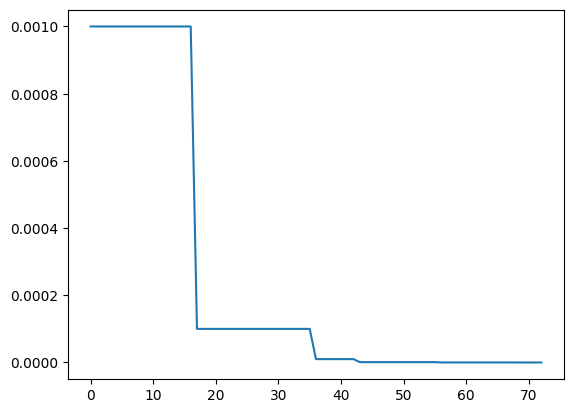

In [120]:
plt.plot(lr_list)

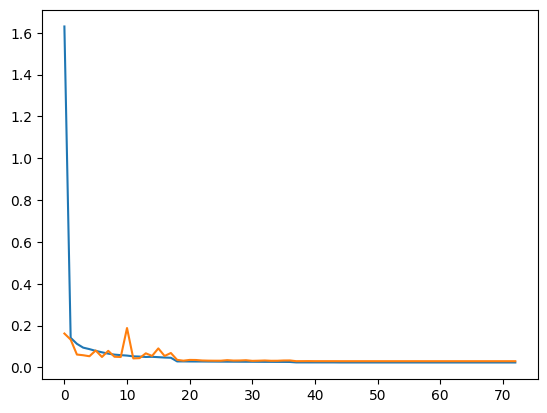

In [121]:
plt.plot(train_loss)
plt.plot(val_loss)

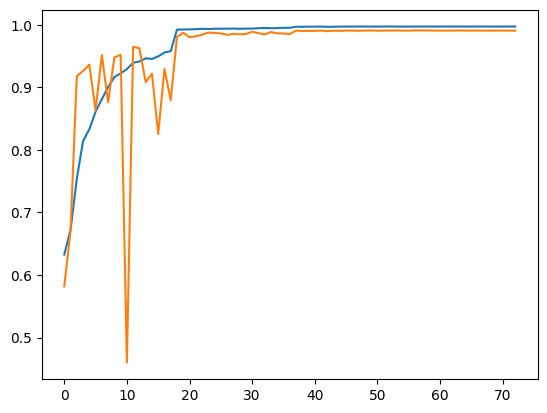

In [122]:
plt.plot(train_acc)
plt.plot(val_acc)

In [124]:
checpoint = torch.load(r'C:\Users\arato\Desktop\It_programms\PyTorch\model_state_dict_epoch_67.pt')
model.load_state_dict(checpoint['state_model'])

<All keys matched successfully>

In [126]:
model.eval()
with torch.no_grad():
    running_test_loss = []
    true_answer = 0
    for x, targets in test_loader:
        x = x.reshape(-1, 64*64).to(device)
        targets = targets.to(device)

        pred = model(x)
        loss = loss_model(pred, targets)

        running_test_loss.append(loss.item())
        mean_test_loss = sum(running_test_loss) / len(running_test_loss)

        true_answer += (torch.round(pred) == targets).all(dim=1).sum().item()

    running_test_acc = true_answer / len(test)

print(f'test_loss = {mean_test_loss:.4f}, test_acc = {running_test_acc:.4f}')

test_loss = 0.0301, test_acc = 0.9893


### Посмотрим предсказания модели

Pred coord:        tensor([24.6939, 22.8746])
Pred round-coord: tensor([25., 23.])
True coord:        [25 23]


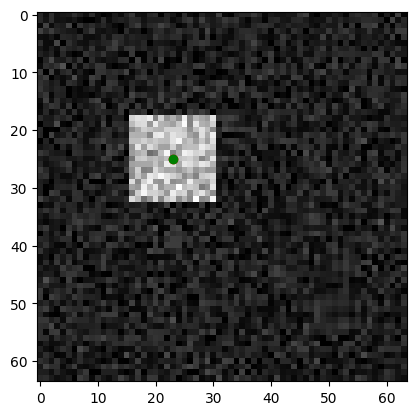

In [127]:
img, coord = test[100]

model.eval()

pred = model(img.view(1, 64*64).to(device)).detach().cpu()

x_pred = torch.round(pred[0])[1].item()
y_pred = torch.round(pred[0])[0].item()

print(f'Pred coord:        {pred[0]}')
print(f'\033[31mPred round-coord:\033[0m {torch.round(pred[0])}')
print(f'\033[32mTrue coord:\033[0m        {coord}')

plt.imshow(img[0].numpy(), cmap='gray')
plt.plot(x_pred, y_pred, marker='o', color='red')
plt.plot(coord[1].item(), coord[0].item(), marker='o', color='green')
plt.show()

In [128]:
model.eval()
test_loader = DataLoader(test, batch_size=len(test))

x, targets = next(iter(test_loader))

print(x.shape)
print(targets.shape)

torch.Size([20000, 1, 64, 64])
torch.Size([20000, 2])


### Неправильные предсказания модели

In [129]:
pred = model(x.reshape(-1, 64*64).to(device)).detach().cpu()

index = ~(torch.round(pred) == targets).all(dim=1)
print(f"Из {len(test)} \033[31mНЕправильно\033[0m предсказано {index.sum()}.", end='\n\n')

imgs_false_pred = x[index]
false_pred = pred[index]
rel_false_pred = targets[index]

Из 20000 НЕправильно предсказано 213.



Pred coord:        tensor([34.7613, 20.4558])
Pred round-coord: tensor([35., 20.])
True coord:        tensor([35, 21])


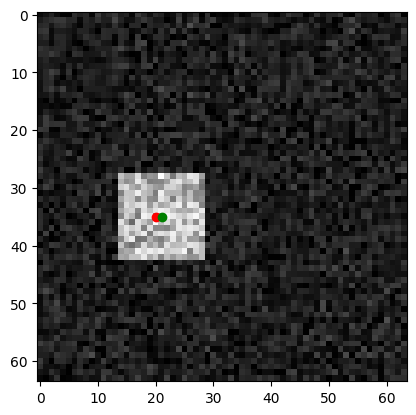

In [130]:
index_false_pred = 1
false_coords = false_pred[index_false_pred]
rel_coords = rel_false_pred[index_false_pred]

print(f'Pred coord:        {false_coords}')
print(f'\033[31mPred round-coord:\033[0m {torch.round(false_coords)}')
print(f'\033[32mTrue coord:\033[0m        {rel_coords}')

x_pred = torch.round(false_coords)[1].item()
y_pred = torch.round(false_coords)[0].item()

plt.imshow(imgs_false_pred[index_false_pred][0].numpy(), cmap='gray')
plt.plot(x_pred, y_pred, marker='o', color='red')
plt.plot(rel_coords[1].item(), rel_coords[0].item(), marker='o', color='green')
plt.show()

Разница всего лишь в 1 пиксель по 1 координате